In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from h5 import HDFArchive
from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
color_list = sns.color_palette('colorblind') + sns.color_palette("Set2") + sns.color_palette("Set3")

dim = 3
save_dir = f'data/{dim}d/rpa'

Starting serial run at: 2026-07-03 08:00:07.582897


SCBA: nk=50^2, niw=128, T=0.1000, mu=0.0000, v=0.050  [numpy.fft]
Converged at step    4  diff=3.636e-11  mu=-0.314818


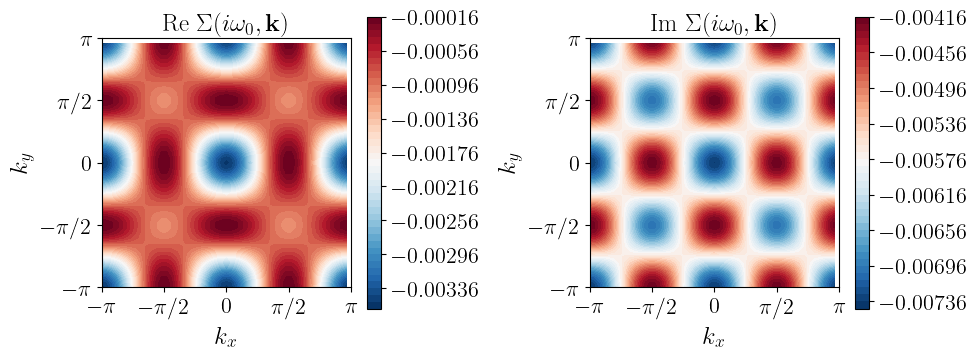

In [ ]:
from scripts.scba import *

lat = LATTICE(dim=2)
nk = 50
bz = BZ(lat, nk=nk)

kx = np.linspace(-np.pi, np.pi, nk, endpoint=False)
ky = np.linspace(-np.pi, np.pi, nk, endpoint=False)
kx, ky = np.meshgrid(kx, ky, indexing='ij')

niw = 128
beta = 1/0.1
n = 0.85
scba = SCBA(lat, bz, niw)
scba.run(0.05, beta, n, ibz=True)

S_iwk = bz.unfold_f_iwk(scba.S_iwk)

S_grid = S_iwk.reshape(niw,nk,nk)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

c0 = axes[0].contourf(kx, ky, S_grid[0].real, levels=50, cmap='RdBu_r')
plt.colorbar(c0, ax=axes[0])
axes[0].set_title(r'Re $\Sigma(i\omega_0, \mathbf{k})$')

c1 = axes[1].contourf(kx, ky, S_grid[0].imag, levels=50, cmap='RdBu_r')
plt.colorbar(c1, ax=axes[1])
axes[1].set_title(r'Im $\Sigma(i\omega_0, \mathbf{k})$')

for ax in axes:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1366: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = z.max().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/matplotlib/contour.py:1367: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = z.min().astype(float)
/home/carlo/micromamba/envs/triqs_env/lib/python3.12/site-packages/numpy/ma/core.py:2885: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


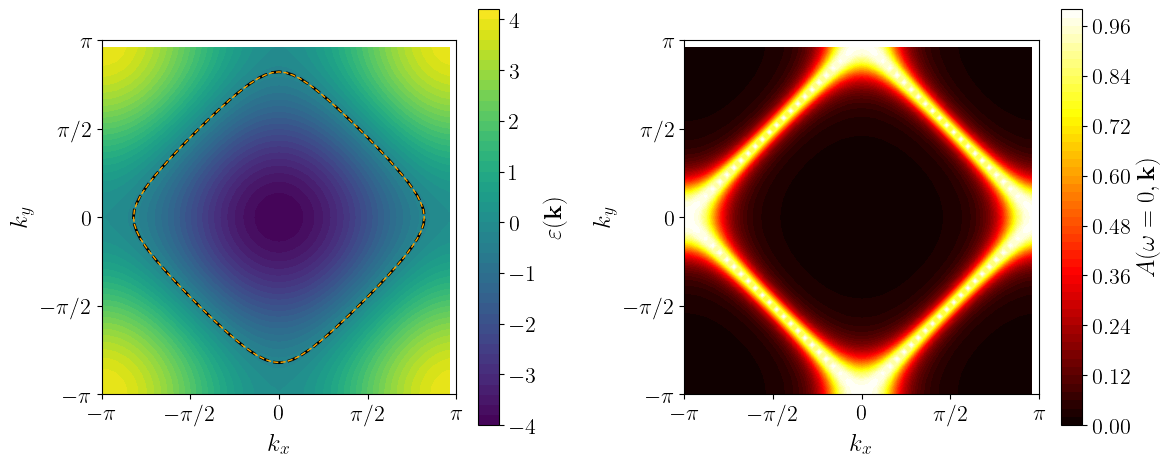

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

lat = LATTICE(dim=2)
bz = BZ(lat, nk=nk, ibz=False)

e_k = bz.e_k.reshape(nk,nk)
Sk0_real = S_iwk[0].reshape(nk,nk)

kx = bz.k_vecs[:,0].reshape(nk,nk)
ky = bz.k_vecs[:,1].reshape(nk,nk)
kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)
Sk0_real = np.roll(np.roll(Sk0_real, nk//2, axis=0), nk//2, axis=1)

G_k_n0 = 1.0 / (1j * np.pi / beta - e_k - Sk0_real)
A_k0 = -G_k_n0.imag / np.pi

cf = axs[0].contourf(kx, ky, e_k - Sk0_real, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')

mu = get_mu(e_k=bz.e_k, n_goal=0.85, beta=1/0.1)
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)
axs[0].contour(kx, ky, e_k - Sk0_real, levels=[mu], colors='orange', linewidths=1)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

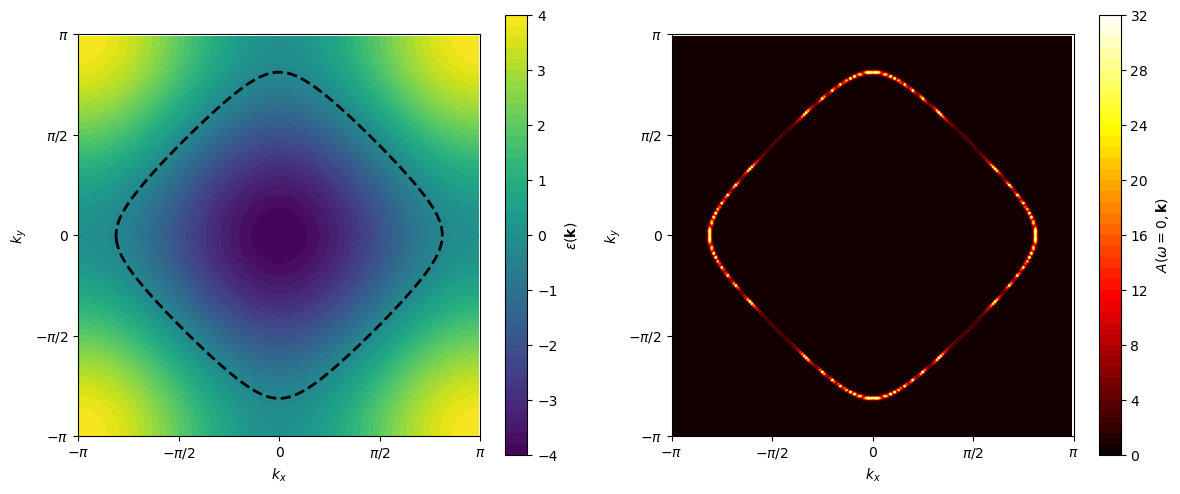

In [ ]:
lat = LATTICE(dim=2)
nk = 200

lat.get_bz(nk, ibz=False)
lat.get_e_k()

kx = lat.k_vecs[:,0].reshape(nk,nk)
ky = lat.k_vecs[:,1].reshape(nk,nk)
e_k = lat.e_k.reshape(nk,nk)

kx -= np.pi
ky -= np.pi
e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

mu = get_mu(e_k=lat.e_k, n_goal=0.9, beta=1/1)
eta = 0.01
A_k0 = (1/np.pi) * eta / (eta**2 + (e_k - mu)**2)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

cf = axs[0].contourf(kx, ky, e_k, levels=50)
plt.colorbar(cf, ax=axs[0], label=r'$\varepsilon(\mathbf{k})$')
axs[0].contour(kx, ky, e_k, levels=[mu], colors='black', linewidths=2)

cf = axs[1].contourf(kx, ky, A_k0, levels=50, cmap='hot')
plt.colorbar(cf, ax=axs[1], label=r'$A(\omega=0, \mathbf{k})$')

for ax in axs:
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

tp : -0.2, mu : [-0.8517850759228668, -0.6716672852022249, -0.46057022123212055], n = [np.float64(0.8), np.float64(0.8999999999998523), np.float64(1.0000000000000262)]
tp : 0.0, mu : [-0.43826440547706147, -0.19845687535815118, 3.907985046680551e-14], n = [np.float64(0.7999999999999953), np.float64(0.8999999999999952), np.float64(1.0000000000000207)]
tp : 0.2, mu : [-0.11835108272199893, 0.19757301236606614, 0.4605702212320972], n = [np.float64(0.8000000000001253), np.float64(0.9000000000000007), np.float64(0.9999999999999641)]


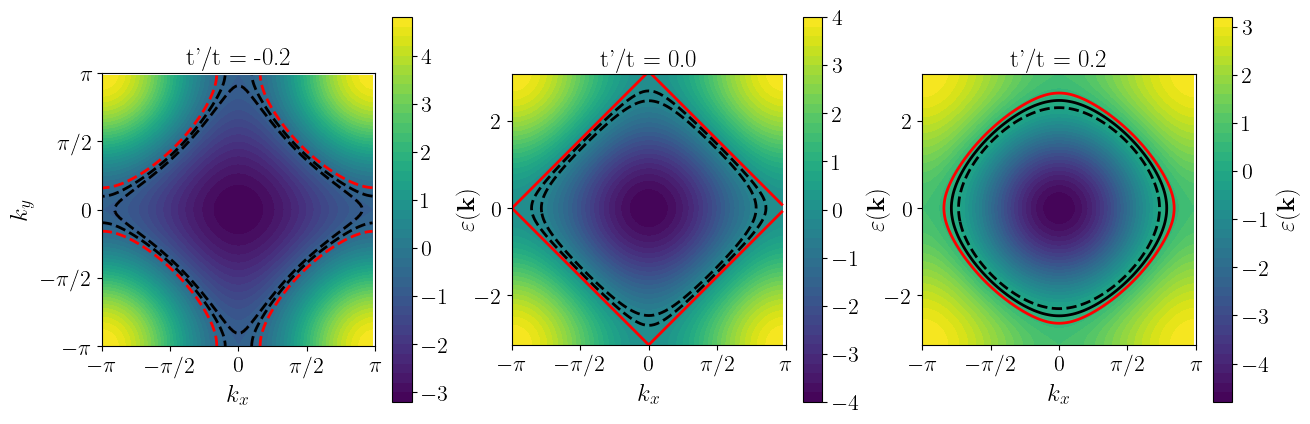

In [116]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

tp_list = [-0.2, 0., 0.2]
for i, tp in enumerate([-0.2, 0., 0.2]):

    lat = LATTICE(dim=2, tp=tp)
    nk = 100

    lat.get_bz(nk, ibz=False)
    lat.get_e_k()

    kx = lat.k_vecs[:,0].reshape(nk,nk)
    ky = lat.k_vecs[:,1].reshape(nk,nk)
    e_k = lat.e_k.reshape(nk,nk)

    kx -= np.pi
    ky -= np.pi
    e_k = np.roll(np.roll(e_k, nk//2, axis=0), nk//2, axis=1)

    T = 0.1
    n_list = [0.8, 0.9, 1.]
    mu_list = [get_mu(e_k=lat.e_k, n_goal=n, beta=1/T) for n in n_list]
    n_check = [2*np.mean(1/(np.exp((lat.e_k-mu)/T)+1)) for mu in mu_list]

    cf = axs[i].contourf(kx, ky, e_k, levels=50)
    plt.colorbar(cf, ax=axs[i], label=r'$\varepsilon(\mathbf{k})$')
    axs[i].contour(kx, ky, e_k, levels=mu_list[:-1], colors='black', linewidths=2)
    axs[i].contour(kx, ky, e_k, levels=[mu_list[-1]], colors='red', linewidths=2)
    print(f'tp : {tp}, mu : {mu_list}, n = {n_check}')

    axs[i].set_title(f"t'/t = {tp}")

    axs[i].set_xlabel(r'$k_x$')
    axs[i].set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    axs[i].set_aspect('equal')

axs[0].set_ylabel(r'$k_y$')
axs[0].set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], labels=[r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])

plt.show()

<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'
<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'
/home/carlo/Desktop/qc/scripts/plot.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  #bbox_to_anchor=(0.63, 0.08, 1, 1),


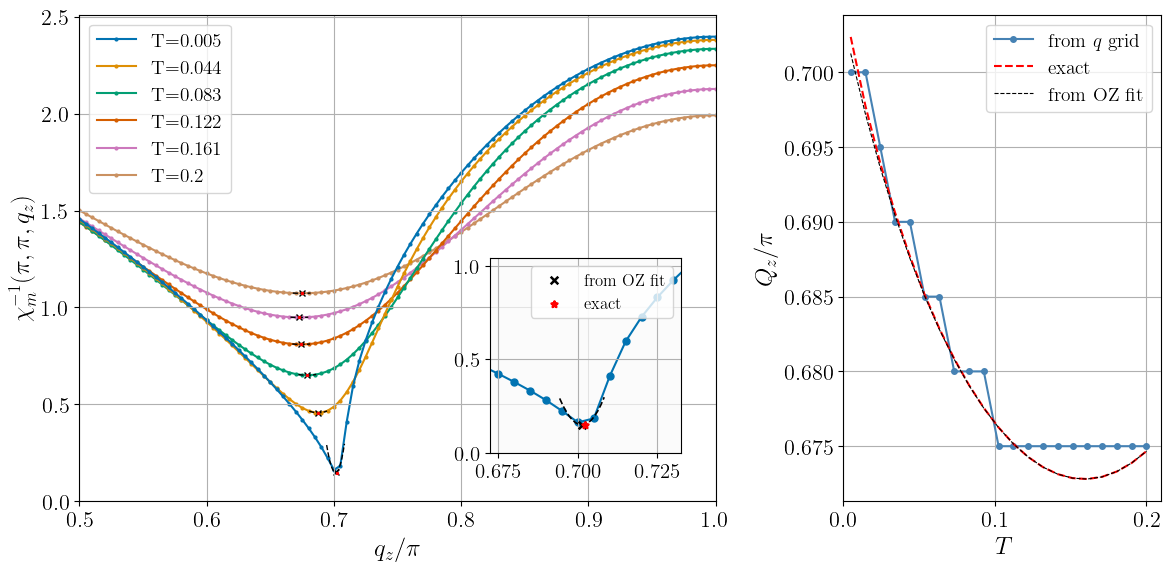

In [29]:
n = 0.745
U = 3

with HDFArchive(f"data/chimin/tp0n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

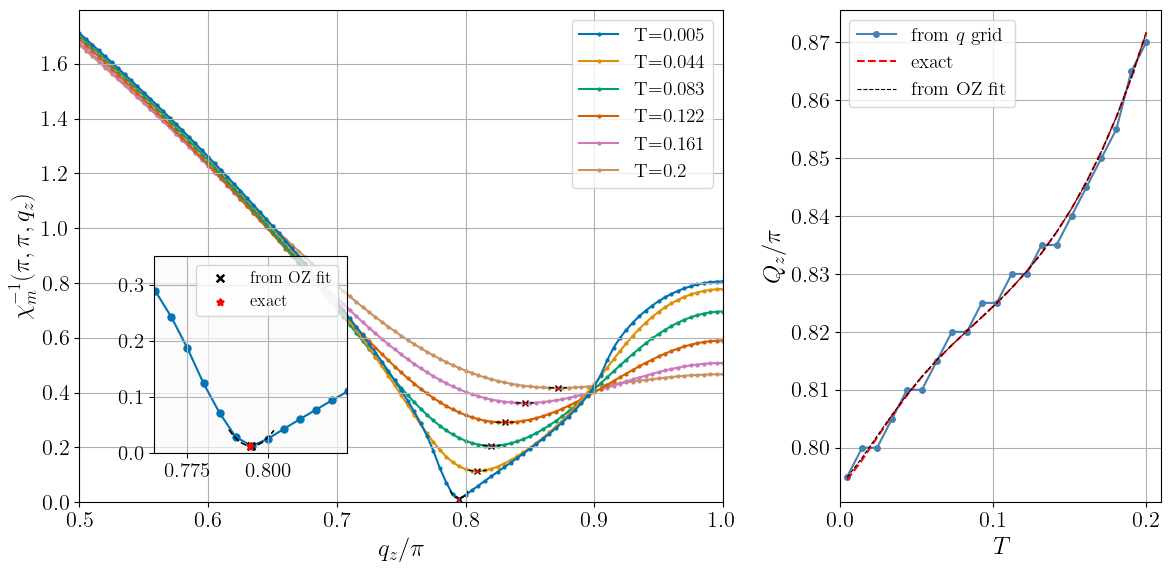

In [26]:
n = 0.8485
U = 3
tp = 0.1

with HDFArchive(f"data/chimin/tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'
<unknown>:36: SyntaxWarning: invalid escape sequence '\p'
<unknown>:40: SyntaxWarning: invalid escape sequence '\p'


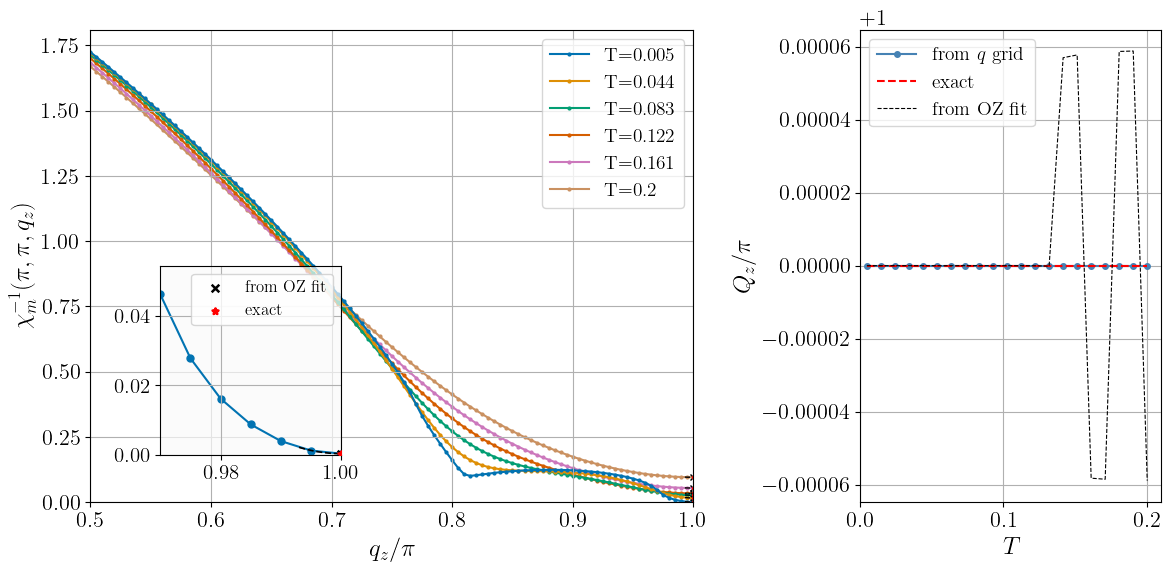

In [25]:
n = 0.88493
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/chimin/tp{tp:.5g}n{n:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_chimin(data)
plt.show()

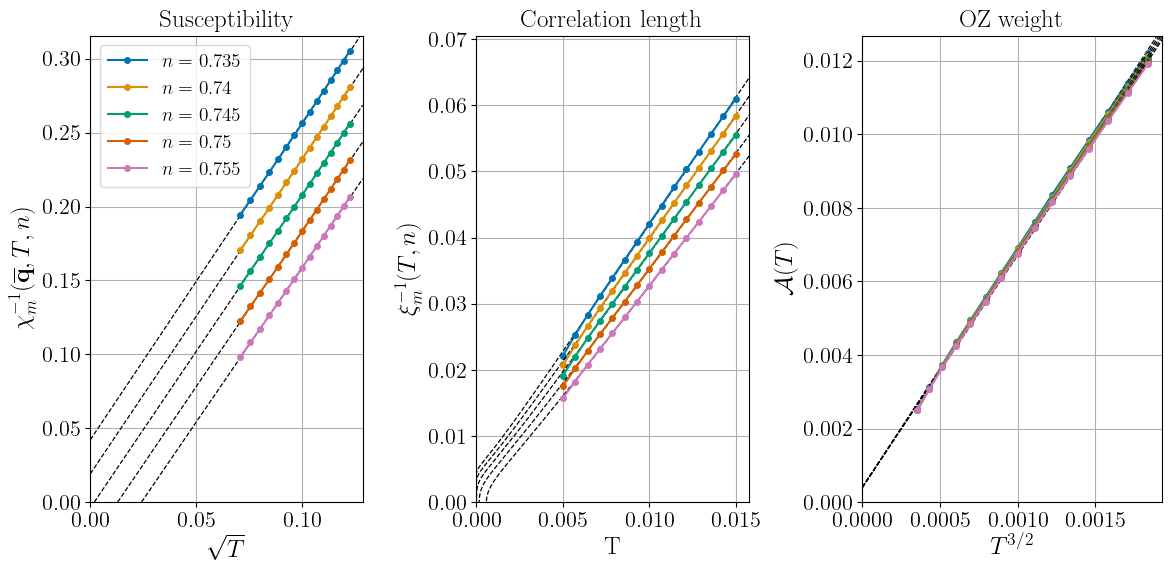

In [3]:
U = 3
tp = 0.

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(0.5, 1., 1.5), fit=True, right='OZ')
plt.show()

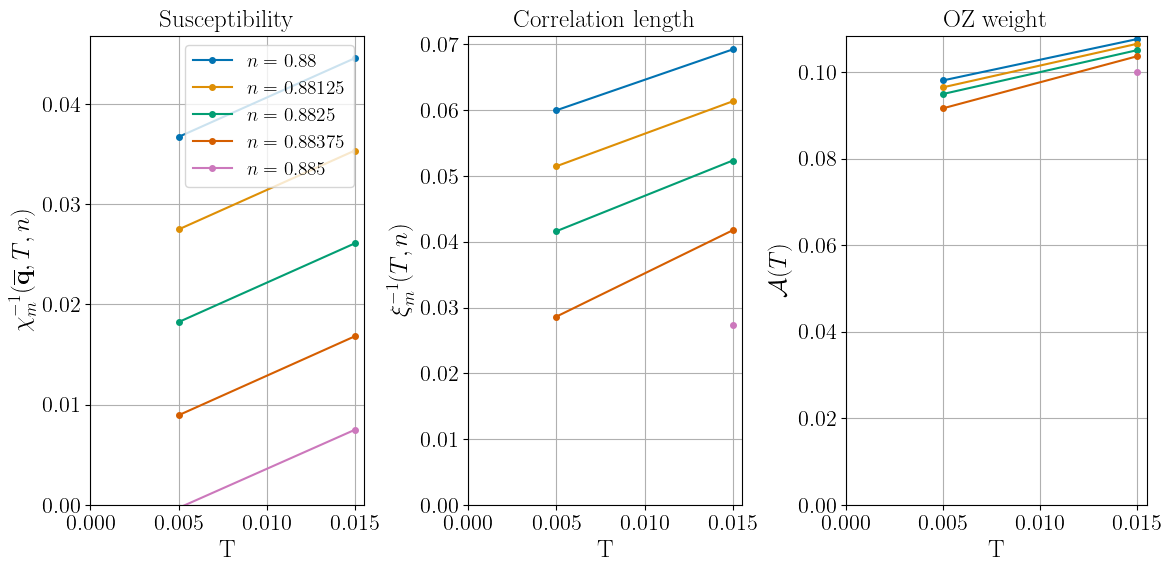

In [4]:
U = 3
tp = 0.1

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(1., 1., 1.), fit=True, right='OZ')
plt.show()

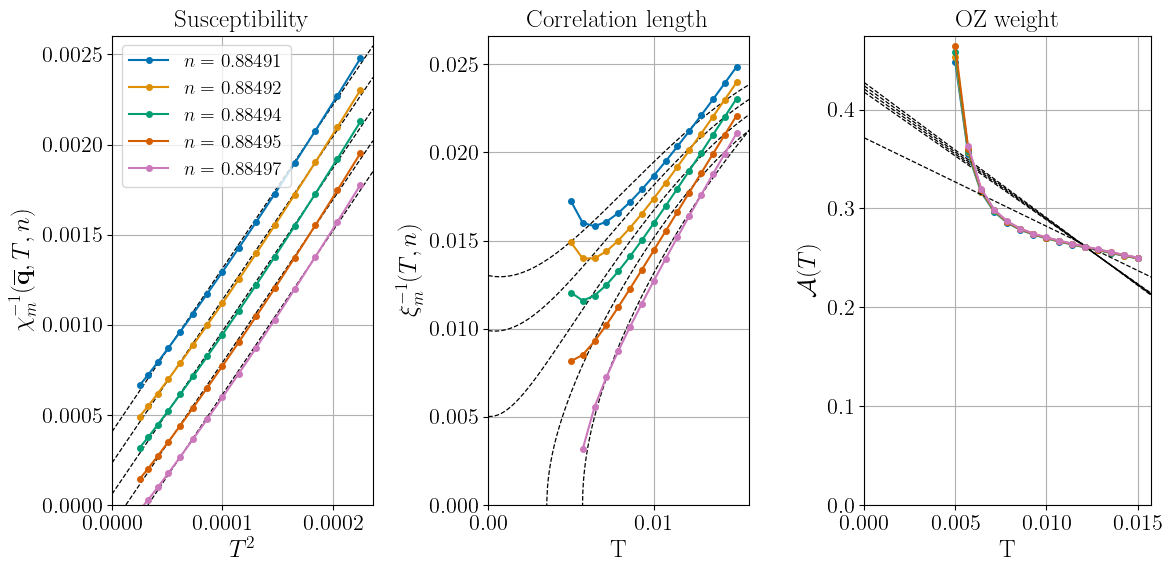

In [5]:
U = 3
tp = 0.2

data = {}
with HDFArchive(f"data/scaling/G0tp{tp:.5g}U{U:.5g}.h5", "r") as ar:
    data = {k: ar[k] for k in ar}

plot_scaling(data, x_exp=(2., 1., 1.), fit=True, right='OZ')
plt.show()

Starting serial run at: 2026-06-17 01:25:35.990065
Starting serial run at: 2026-06-17 01:25:36.001687
Starting serial run at: 2026-06-17 01:25:36.050457
Starting serial run at: 2026-06-17 01:25:36.093508


Starting serial run at: 2026-06-17 01:25:36.191719


U: 3.000, n: 0.730: Completed 20 jobs in 329.7 seconds
U: 3.000, n: 0.738: Completed 20 jobs in 378.6 seconds
U: 3.000, n: 0.746: Completed 20 jobs in 342.5 seconds
U: 3.000, n: 0.753: Completed 20 jobs in 344.5 seconds
U: 3.000, n: 0.761: Completed 20 jobs in 355.2 seconds
U: 3.000, n: 0.769: Completed 20 jobs in 388.6 seconds
U: 3.000, n: 0.777: Completed 20 jobs in 332.2 seconds
U: 3.000, n: 0.785: Completed 20 jobs in 347.3 seconds
U: 3.000, n: 0.793: Completed 20 jobs in 333.9 seconds
U: 3.000, n: 0.800: Completed 20 jobs in 383.5 seconds
U: 3.000, n: 0.808: Completed 20 jobs in 324.4 seconds
U: 3.000, n: 0.816: Completed 20 jobs in 339.1 seconds
U: 3.000, n: 0.824: Completed 20 jobs in 331.3 seconds
U: 3.000, n: 0.832: Completed 20 jobs in 341.6 seconds
U: 3.000, n: 0.840: Completed 20 jobs in 333.8 seconds
U: 3.000, n: 0.847: Completed 20 jobs in 329.4 seconds
U: 3.000, n: 0.855: Completed 20 jobs in 305.4 seconds
U: 3.000, n: 0.863: Completed 20 jobs in 300.3 seconds
U: 3.000, 

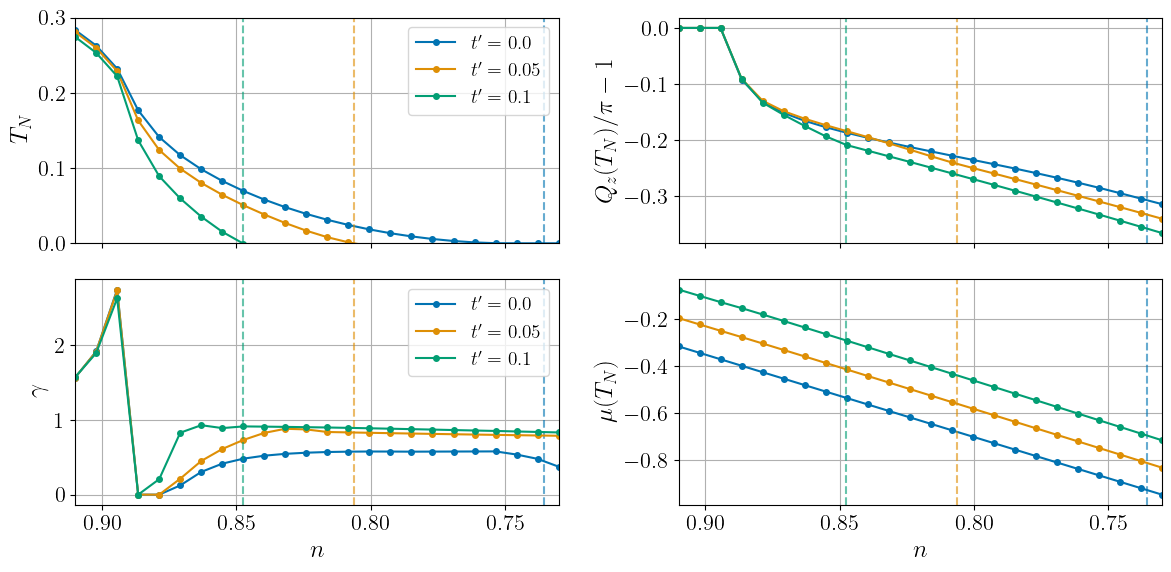

In [31]:
n_old = n_list1

U = 3
n_list1 = np.linspace(0.73, 0.91, 24)
T_list = np.linspace(0., 0.06, 20)

#prev_Tc1 = np.zeros((3, len(n_list1)))
prev_Tc1 = [np.interp(n_list1, n_old, Tc1[j][:]) for j in range(3)]

nk = 200
tp_list = [0., 0.05, 0.1]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

fig = plt.figure(figsize=(12, 6))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
fig.subplots_adjust(hspace=0.15, wspace=0.03)

for a in ax:
    a.grid()
    a.set_xlim(n_list1[0], n_list1[-1])
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel(r'$T_N$')
ax[1].set_ylabel(r'$\gamma$')
ax[2].set_ylabel(r'$Q_z(T_N)/\pi - 1$')
ax[3].set_ylabel(r'$\mu(T_N)$')

ax[0].tick_params(axis='x', labelbottom=False)
ax[2].tick_params(axis='x', labelbottom=False)
ax[1].set_xlabel(r'$n$')
ax[3].set_xlabel(r'$n$')

Tc1 = prev_Tc1.copy()
for j, tp in enumerate(tp_list):

    lat = LATTICE(tp=tp)
    initialize_bz(lat, nk, refine=True, refine_ratio=2)

    results_list = []
    for i, n in enumerate(n_list1):
        par_list = [{'U': U, 'n': n, 'T': T} for T in  T_list + max(prev_Tc1[j][i], 0.01)]
        results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.5],[1,1,1]), method='local', get_xi=False, fit=True, workers=5))

    Tc1[j][:] = [res['fitchi']['Xc'] for res in results_list]
    gamma = [res['fitchi']['b'] for res in results_list]
    Qc = [res['Qc'][-1]-1 for res in results_list]
    muc = [res['mu_c'][0] for res in results_list]

    line = ax[0].plot(n_list1, Tc1[j][:], 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])
    ax[1].plot(n_list1, gamma, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])
    ax[2].plot(n_list1, Qc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])
    ax[3].plot(n_list1, muc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[j])

    nc = np.interp(0., Tc1[j][:], n_list1)
    for a in ax:
        a.axvline(nc, linestyle='--', color=color_list[j], alpha=0.6)

ax[0].legend()
ax[1].legend()

print(Tc1)
fig.tight_layout()
plt.show()

Starting serial run at: 2026-06-17 07:57:17.109770
Starting serial run at: 2026-06-17 07:57:17.162639
Starting serial run at: 2026-06-17 07:57:17.168013
Starting serial run at: 2026-06-17 07:57:17.219315
Starting serial run at: 2026-06-17 07:57:17.285051


U: 3.000, n: 0.870: Completed 20 jobs in 77.3 seconds
U: 3.000, n: 0.872: Completed 20 jobs in 77.9 seconds
U: 3.000, n: 0.873: Completed 20 jobs in 74.5 seconds
U: 3.000, n: 0.875: Completed 20 jobs in 74.1 seconds
U: 3.000, n: 0.877: Completed 20 jobs in 78.8 seconds
U: 3.000, n: 0.879: Completed 20 jobs in 76.9 seconds
U: 3.000, n: 0.880: Completed 20 jobs in 80.7 seconds
U: 3.000, n: 0.882: Completed 20 jobs in 77.9 seconds
U: 3.000, n: 0.884: Completed 20 jobs in 77.9 seconds
U: 3.000, n: 0.886: Completed 20 jobs in 72.6 seconds
U: 3.000, n: 0.887: Completed 20 jobs in 70.7 seconds
U: 3.000, n: 0.889: Completed 20 jobs in 40.5 seconds
U: 3.000, n: 0.891: Completed 20 jobs in 40.4 seconds
U: 3.000, n: 0.893: Completed 20 jobs in 40.2 seconds
U: 3.000, n: 0.894: Completed 20 jobs in 39.7 seconds
U: 3.000, n: 0.896: Completed 20 jobs in 40.0 seconds
U: 3.000, n: 0.898: Completed 20 jobs in 39.6 seconds
U: 3.000, n: 0.900: Completed 20 jobs in 40.0 seconds
U: 3.000, n: 0.901: Complete

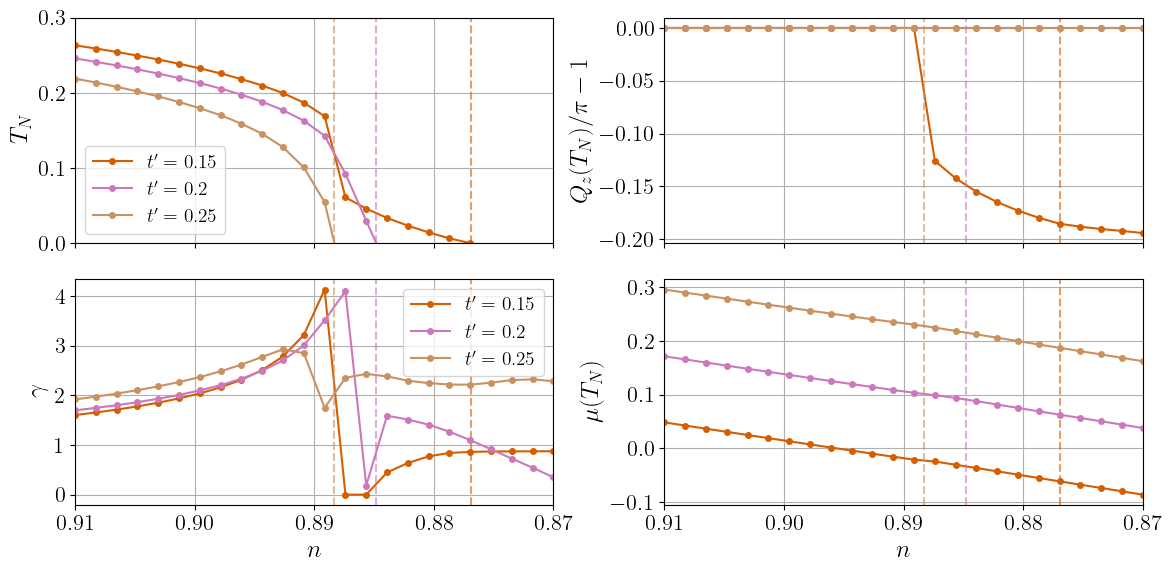

In [32]:
n_old = n_list2

U = 3
n_list2 = np.linspace(0.87, 0.91, 24)
T_list = np.linspace(0., 0.06, 20)

#prev_Tc2 = np.zeros((3, len(n_list2)))
prev_Tc2 = [np.interp(n_list2, n_old, Tc2[j][:]) for j in range(3)]

nk = 130
tp_list = [0.15, 0.2, 0.25]

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif"
})

fig = plt.figure(figsize=(12, 6))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
fig.subplots_adjust(hspace=0.15, wspace=0.03)

for a in ax:
    a.grid()
    a.set_xlim(n_list2[0], n_list2[-1])
    a.invert_xaxis()

ax[0].set_ylim(0., 0.3)
#ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel(r'$T_N$')
ax[1].set_ylabel(r'$\gamma$')
ax[2].set_ylabel(r'$Q_z(T_N)/\pi - 1$')
ax[3].set_ylabel(r'$\mu(T_N)$')

ax[0].tick_params(axis='x', labelbottom=False)
ax[2].tick_params(axis='x', labelbottom=False)
ax[1].set_xlabel(r'$n$')
ax[3].set_xlabel(r'$n$')

Tc2 = prev_Tc2.copy()
for j, tp in enumerate(tp_list):

    lat = LATTICE(tp=tp)
    initialize_bz(lat, nk, refine=True, refine_ratio=2)

    results_list = []
    for i, n in enumerate(n_list2):
        par_list = [{'U': U, 'n': n, 'T': T} for T in  T_list + max(prev_Tc2[j][i], 0.01)]
        results_list.append(sweep_rpa(par_list, lat, q_path=([1,1,0.5],[1,1,1]), method='local', get_xi=False, fit=True, workers=5))

    Tc2[j][:] = [res['fitchi']['Xc'] for res in results_list]
    gamma = [res['fitchi']['b'] for res in results_list]
    Qc = [res['Qc'][-1]-1 for res in results_list]
    muc = [res['mu_c'][0] for res in results_list]

    line = ax[0].plot(n_list2, Tc2[j][:], 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])
    ax[1].plot(n_list2, gamma, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])
    ax[2].plot(n_list2, Qc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])
    ax[3].plot(n_list2, muc, 'o-', label=rf"$t'={tp}$", markersize=4, color=color_list[3+j])

    nc = np.interp(0., Tc2[j][:], n_list2)
    for a in ax:
        a.axvline(nc, linestyle='--', color=color_list[3+j], alpha=0.6)

ax[0].legend()
ax[1].legend()

print(Tc2)
fig.tight_layout()
plt.show()

In [ ]:
print(Tc2)

[array([-0.02045428, -0.00856195, -0.00181113,  0.00072029,  0.00433789,
        0.00913734,  0.01594448,  0.02495022,  0.03089112,  0.03467473,
        0.06234645,  0.17024629,  0.18772693,  0.20011302,  0.21009421,
        0.21859773,  0.2260738 ,  0.23278102,  0.23888397,  0.24449499,
        0.24969475,  0.2545435 ,  0.25908759,  0.26336362]), array([-2.71161010e+00, -4.63290823e-09, -4.13293660e-09, -3.50764123e-09,
       -3.73939104e-09, -2.36405673e-09, -4.70965173e-09, -3.16401004e-09,
        3.90415541e-03,  2.80938604e-02,  9.46925382e-02,  1.43783428e-01,
        1.63522252e-01,  1.77406248e-01,  1.88469281e-01,  1.97807380e-01,
        2.05956197e-01,  2.13222814e-01,  2.19801762e-01,  2.25825044e-01,
        2.31386941e-01,  2.36557447e-01,  2.41390173e-01,  2.45927208e-01]), array([-0.37898587, -0.33547605, -0.29726989, -0.26570991, -0.23833888,
       -0.21153674, -0.18410591, -0.15709071, -0.1308355 , -0.10275311,
       -0.06399933,  0.04803951,  0.10143376,  0.12822